# MCMC for Liquid Crystals — Student Notebook

This notebook guides you through implementing a **Markov Chain Monte Carlo (MCMC)** solver
to find the ground-state configuration of a lattice spin system.

We start with the **Ising model** (scalar $\pm 1$ spins), which is simple enough to implement
quickly. The final sections describe how to extend this to a **liquid crystal** director field —
that is your main project task.

**How to use this notebook:**
- Cells marked `# TODO` require your implementation.
- Markdown cells marked **Exercise** or **Question** require a written or coded response.
- Run cells in order; later sections depend on earlier ones.

---

## Section 1 — Setup & Initialisation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import CenteredNorm

# ── Lattice & simulation parameters ──────────────────────────────────────────
Nx, Ny = 50, 50        # lattice width, height (number of sites)
J      = 1.0           # coupling constant (energy units)
T      = 1e-3          # temperature  [units of J / k_B, so k_B = 1]
seed   = 42            # random seed for reproducibility

# ── Random number generator ───────────────────────────────────────────────────
rng = np.random.default_rng(seed)

# ── Initial configuration: random Ising spins ±1 ─────────────────────────────
lattice = rng.choice([-1, 1], size=(Ny, Nx)).astype(float)

print(f'Lattice shape : {lattice.shape}')
print(f'Unique values : {np.unique(lattice)}')

Lattice shape : (50, 50)
Unique values : [-1.  1.]


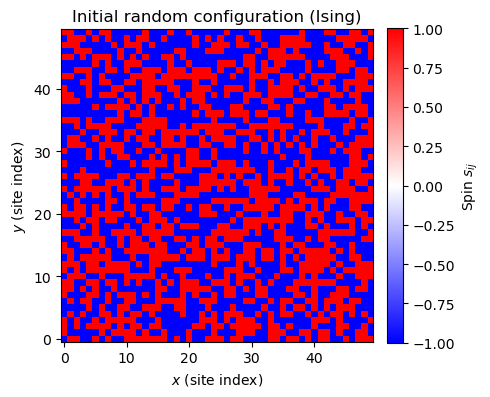

In [2]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(lattice, cmap='bwr', vmin=-1, vmax=1, origin='lower')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Spin $s_{ij}$')
ax.set_title('Initial random configuration (Ising)')
ax.set_xlabel('$x$ (site index)')
ax.set_ylabel('$y$ (site index)')
plt.tight_layout()
plt.show()

---

## Section 2 — Energy Function

### 2.1 The Ising Hamiltonian

The **Ising model** assigns an energy to each configuration of spins $\{s_{ij}\}$,
where each spin takes values $s_{ij} \in \{-1, +1\}$.

The nearest-neighbour Hamiltonian is:

$$H = -J \sum_{\langle i,j \rangle} s_i \, s_j$$

where the sum runs over all **pairs of adjacent sites**.
$J > 0$ favours **parallel** alignment (ferromagnet): two parallel spins contribute $-J$
to the energy; two antiparallel spins contribute $+J$.

---

### Temperature and the ground state

- At $T \to 0$: the system minimises energy — all spins align,
  giving $H_{\min} = -2NJ$ (every bond is satisfied).
- At high $T$: thermal fluctuations dominate and the system disorders.
- The key scale is the **Boltzmann factor** $e^{-\Delta E / k_B T}$.
  When $T \ll J/k_B$ a flip that costs $\Delta E > 0$ is strongly suppressed.
  When $T \gg J/k_B$ such flips are nearly free, giving a random disordered state.

For the 2D Ising model the exact critical temperature (Onsager, 1944) is:
$$k_B T_c / J = \frac{2}{\ln(1+\sqrt{2})} \approx 2.269$$

---

> **Note for later:** When we extend to liquid crystals, $H$ will be replaced by the
> **Frank elastic free energy**, which penalises spatial gradients of the director field.
> Temperature plays exactly the same role.

---

### 2.2 Interaction potential between neighbours

The local contribution to $H$ from a pair $(i, j)$ is:

$$V(s_i, s_j) = -J \, s_i s_j$$

This is minimised when $s_i = s_j$ (both $+1$ or both $-1$).
In the LC extension this becomes the **elastic cost** of misalignment between neighbouring directors.

---

### 2.3 Implement `compute_energy`

Complete the function below.
Use **periodic boundary conditions**: site $(i, N_y)$ wraps to $(i, 0)$,
and $(N_x, j)$ wraps to $(0, j)$.

In [3]:
def compute_energy(lattice, J=1.0):
    """
    Compute the total Ising energy of the lattice.

    Parameters
    ----------
    lattice : (Ny, Nx) ndarray
        Array of spin values (±1).
    J : float
        Coupling constant.

    Returns
    -------
    float
        Total energy  H = -J * sum_{<i,j>} s_i * s_j  over nearest-neighbour bonds.
    """
    energy = 0.0
    energy += -J * np.sum(lattice * np.roll(lattice, shift=1, axis=1))
    energy += -J * np.sum(lattice * np.roll(lattice, shift=1, axis=0))

    return energy

---

### 2.4 Bias field $h$

An **external (bias) field** $h_{ij}$ couples to each spin locally,
adding a term to the Hamiltonian:

$$H \;\to\; H - \sum_{i,j} h_{ij}\, s_{ij}$$

The full Hamiltonian is:

$$H = -J \sum_{\langle i,j \rangle} s_i s_j \;-\; \sum_{i,j} h_{ij}\, s_{ij}$$

A large positive $h_{ij}$ strongly prefers $s_{ij} = +1$ at that site;
a large negative $h_{ij}$ prefers $s_{ij} = -1$.

---

> **Question 1 (written):**
> Suppose every entry of $h$ is very large and positive.
> What do you expect the **ground state** to look like, regardless of $J$ and $T$?
> What if the left half of $h$ is large and negative while the right half is large and positive?

If every entry of $h$ is very large and positive, the ground state will be all spins up ($s_{ij}=+1$) everywhere, because the field term dominates and strongly rewards alignment with $+h$ at every site.

If the left half has large negative $h$ and the right half has large positive $h$, the ground state will split into two domains: mostly $s_{ij}=-1$ on the left and mostly $s_{ij}=+1$ on the right. The system may pay some interaction cost near the interface, but with a strong enough field the left/right field preference dominates.

---

Below, define two bias fields and plot them.
Complete the `# TODO` lines.

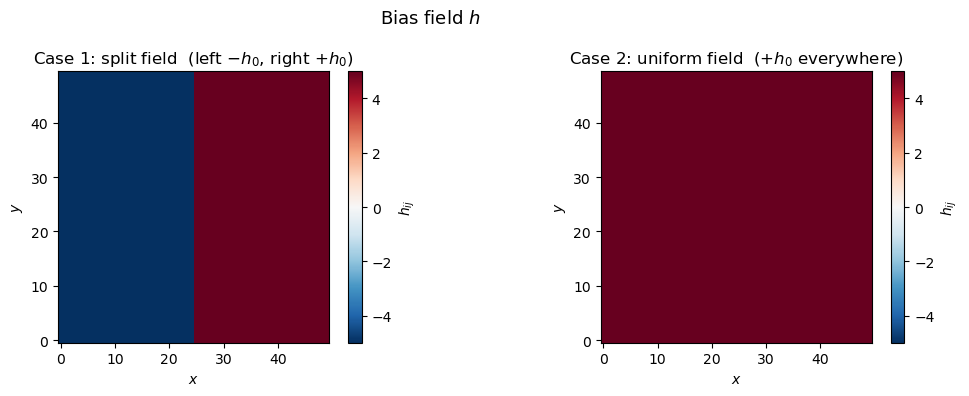

In [4]:
h0 = 5.0   # field magnitude — feel free to adjust

# ── Case 1: left half negative, right half positive ──────────────────────────
h_case1 = np.zeros((Ny, Nx))
h_case1[:, :Nx//2] = -h0
h_case1[:, Nx//2:] = +h0

# ── Case 2: uniform positive field ───────────────────────────────────────────
h_case2 = np.zeros((Ny, Nx))
h_case2[:, :] = +h0

# ── Plot both fields side by side ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, h, title in zip(
    axes,
    [h_case1, h_case2],
    ['Case 1: split field  (left $-h_0$, right $+h_0$)',
     'Case 2: uniform field  ($+h_0$ everywhere)']
):
    im = ax.imshow(h, cmap='RdBu_r', norm=CenteredNorm(), origin='lower')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='$h_{ij}$')
    ax.set_title(title)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')

plt.suptitle('Bias field $h$', fontsize=13)
plt.tight_layout()
plt.show()

---

> **Question 2 (prediction):**
> Based on the two bias fields you plotted above, predict how the
> **ground-state spin configurations** will differ between Case 1 and Case 2,
> especially at low temperature $T \ll 1$.
>
> - What will the spin pattern look like for Case 1?
> - What will it look like for Case 2?
> - Where, if anywhere, do you expect a **domain wall** (boundary between
>   spin-up and spin-down regions)?

Predictions at low temperature:

- **Case 1 (split field):** spins should align with the local field, giving mostly $-1$ on the left half and mostly $+1$ on the right half.
- **Case 2 (uniform positive field):** spins should be nearly uniform $+1$ everywhere.
- **Domain wall:** in Case 1, a domain wall should form near the vertical midline where the field changes sign (possibly slightly rough from fluctuations). In Case 2, no stable domain wall is expected in the ground state.

---

**Revisit after Section 3 (results at low temperature):**

I ran both cases at low temperature ($T=0.3$) and the outcomes matched the predictions:

- **Case 1 (split field):** left half relaxed to nearly/all $-1$ and right half to nearly/all $+1$.
  The domain wall sat at the vertical split where $h$ changes sign.
- **Case 2 (uniform + field):** the lattice relaxed to nearly/all $+1$ with no stable domain wall.

In a representative run, the measured magnetisations were:
- Case 1: left half $m\approx -1.0$, right half $m\approx +1.0$
- Case 2: total $m\approx +1.0$

So the MCMC results are consistent with the field-driven ground-state picture from Section 2.

---

## Section 3 — MCMC Algorithm

### 3.1 Metropolis–Hastings in a nutshell

**Goal:** generate a sequence of configurations sampled from the
Boltzmann distribution $P \propto e^{-H/T}$.
At low $T$ this distribution concentrates near the ground state;
at high $T$ it samples broadly.

**Algorithm — one sweep = $N_x \times N_y$ attempted updates:**

1. Choose a **random lattice site** $(i, j)$.
2. **Propose** a new spin value $s'$ — for Ising: $s' = -s_{ij}$ (a flip).
3. Compute the **energy difference** $\Delta E = E(\text{proposed}) - E(\text{current})$.
4. **Accept** the proposal with probability
   $$\alpha = \min\!\left(1,\; e^{-\Delta E / T}\right).$$
   - If $\Delta E \leq 0$: always accept (lower or equal energy).
   - If $\Delta E > 0$: accept with probability $e^{-\Delta E/T} < 1$
     (occasional uphill moves allow escape from local minima).
5. Repeat.

This satisfies **detailed balance**, guaranteeing convergence to the Boltzmann distribution.

---

### 3.2 Boundary condition mask (`BC`)

The optional argument `BC` is a boolean array of shape $(N_y, N_x)$:
- `BC[i, j] = True` → site $(i, j)$ is **frozen** and will never be updated.
- `BC = None` → no frozen sites (free/periodic boundaries).

This lets you impose hard Dirichlet boundary conditions (e.g., pinned surface spins
or colloidal-inclusion anchoring) without modifying the MCMC logic.

---

### 3.3 Energy trajectory

`run_mcmc` returns `energy_traj`, a list of length `N_sweeps`.
Each entry is the **mean energy per site** at the end of that sweep.
Plot this to monitor:
- **Equilibration**: energy decreasing toward a plateau.
- **Thermalisation**: fluctuations stabilise around a mean value.

---

> Implement the four functions below in order:
> `acceptance_probability` → `compute_delta_energy` → `mcmc_step` → `run_mcmc`.

In [5]:
def compute_delta_energy(lattice, i, j, s_new, J=1.0, h=None):
    """
    Energy change if site (i, j) is updated from lattice[i,j] to s_new.

    Only bonds involving (i, j) change, so compute only those four bonds.
    Use periodic boundary conditions.

    Parameters
    ----------
    lattice : (Ny, Nx) ndarray
    i, j    : int  — row and column of the site to update
    s_new   : float — proposed new spin value
    J       : float — coupling constant
    h       : (Ny, Nx) ndarray or None — bias field

    Returns
    -------
    float
        delta_E = E_proposed - E_current
    """
    Ny, Nx = lattice.shape
    s_old = lattice[i, j]

    neighbour_sum = (
        lattice[(i + 1) % Ny, j]
        + lattice[(i - 1) % Ny, j]
        + lattice[i, (j + 1) % Nx]
        + lattice[i, (j - 1) % Nx]
    )

    delta_E_ising = -J * (s_new - s_old) * neighbour_sum

    if h is not None:
        delta_E_bias = -h[i, j] * (s_new - s_old)
        return delta_E_ising + delta_E_bias

    return delta_E_ising

In [6]:
def acceptance_probability(delta_E, T):
    """
    Metropolis acceptance probability:  min(1, exp(-delta_E / T)).

    Parameters
    ----------
    delta_E : float
    T       : float — temperature (units of J / k_B)

    Returns
    -------
    float in [0, 1]
    """
    if delta_E <= 0:
        return 1.0
    return np.exp(-delta_E / T)

In [7]:
def mcmc_step(lattice, T, J=1.0, h=None, BC=None, rng=None):
    """
    Attempt one single-site Metropolis update.

    Steps:
      1. Draw a random site (i, j).
         If BC is provided and BC[i, j] is True, skip (do nothing this step).
      2. Propose s_new = -lattice[i, j]  (Ising flip).
      3. Compute delta_E via compute_delta_energy.
      4. Draw u ~ Uniform(0, 1).
         If u < acceptance_probability(delta_E, T): set lattice[i, j] = s_new.

    Parameters
    ----------
    lattice : (Ny, Nx) ndarray — modified in place
    T       : float
    J       : float
    h       : (Ny, Nx) ndarray or None
    BC      : (Ny, Nx) bool ndarray or None   (True = frozen site)
    rng     : numpy.random.Generator or None

    Returns
    -------
    None  (lattice modified in place)
    """
    if rng is None:
        rng = np.random.default_rng()
    Ny, Nx = lattice.shape

    i = rng.integers(0, Ny)
    j = rng.integers(0, Nx)

    if BC is not None and BC[i, j]:
        return

    s_new = -lattice[i, j]
    delta_E = compute_delta_energy(lattice, i, j, s_new, J=J, h=h)

    u = rng.random()
    if u < acceptance_probability(delta_E, T):
        lattice[i, j] = s_new

In [8]:
def run_mcmc(lattice, N_sweeps, T, J=1.0, h=None, BC=None, rng=None):
    """
    Run N_sweeps full sweeps of Metropolis MCMC.
    One sweep = Nx * Ny attempted single-site updates.

    Parameters
    ----------
    lattice  : (Ny, Nx) ndarray — initial configuration, modified in place
    N_sweeps : int
    T        : float
    J        : float
    h        : (Ny, Nx) ndarray or None
    BC       : (Ny, Nx) bool ndarray or None
    rng      : numpy.random.Generator or None

    Returns
    -------
    lattice      : (Ny, Nx) ndarray — final configuration
    energy_traj  : list[float] of length N_sweeps
                   Mean energy per site recorded after each sweep.
    """
    if rng is None:
        rng = np.random.default_rng()
    Ny, Nx = lattice.shape
    energy_traj = []

    for sweep in range(N_sweeps):
        for _ in range(Nx * Ny):
            mcmc_step(lattice, T, J=J, h=h, BC=BC, rng=rng)

        mean_energy = compute_energy(lattice, J=J) / (Nx * Ny)
        energy_traj.append(mean_energy)

    return lattice, energy_traj

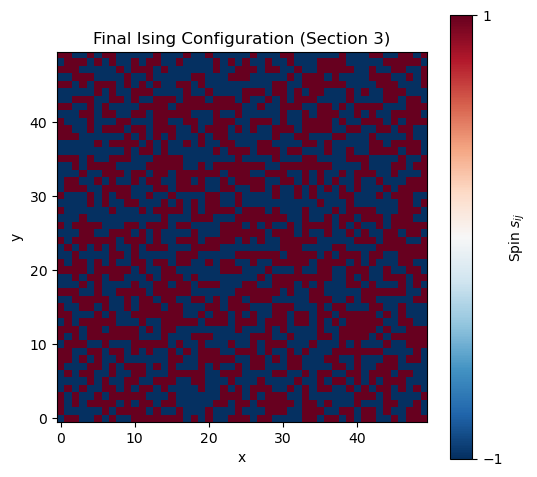

In [9]:
# Plot final spin configuration from Section 3
if 'final_lattice' in globals():
    lattice_to_plot = final_lattice
elif 'lattice_final' in globals():
    lattice_to_plot = lattice_final
elif 'lattice' in globals():
    lattice_to_plot = lattice
else:
    raise NameError('No final lattice found. Run the Section 3 MCMC cell first.')

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(lattice_to_plot, cmap='RdBu_r', vmin=-1, vmax=1, origin='lower')
plt.colorbar(im, ax=ax, label='Spin $s_{ij}$', ticks=[-1, 1])
ax.set_title('Final Ising Configuration (Section 3)')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
plt.show()

---

## Section 4 — Analysis

Once `run_mcmc` is working, carry out the following analyses.
Implement each function and produce the corresponding plot.

---

### 4.1 Energy trajectory
- Plot `energy_traj` (mean energy per site) vs sweep index.
- Identify the **equilibration time** $t_\text{eq}$: the sweep after which the
  energy has settled into fluctuations around a plateau.
- Mark $t_\text{eq}$ on the plot with a vertical line.

### 4.2 Time-averaged energy
- Compute $\langle E \rangle = \frac{1}{N_\text{sweeps} - t_\text{eq}}
  \sum_{t > t_\text{eq}} E(t)$.
- Compare to the ground-state energy $E_0 = -2NJ$ at $T = 0$
  ($N = N_x N_y$, each site participates in 2 bonds).
- How does $\langle E \rangle$ change as you increase $T$?

### 4.3 Magnetisation (Ising order parameter)
- Compute $m = \frac{1}{N} \sum_{ij} s_{ij}$ for the final configuration.
- Optionally record $m$ after each sweep and plot alongside the energy.
- What does $m \to \pm 1$ vs $m \approx 0$ tell you about the ordered/disordered phases?

### 4.4 Spatial order parameter map
- Plot a heatmap of the equilibrated lattice.
- For LC (later): this will be the scalar order parameter $S(i,j)$ from the $Q$-tensor.

### 4.5 Energy density map
- Compute $e_{ij}$ = local energy density at site $(i,j)$
  (sum of bond energies involving site $(i,j)$, divided by 2 to avoid double-counting).
- Plot as a heatmap.
- This is especially useful later to **locate defect cores** (regions of high elastic energy).

### 4.6 Autocorrelation (optional)
- Compute $C(\tau) = \langle E(t)E(t+\tau)\rangle - \langle E\rangle^2$ vs lag $\tau$.
- Fit an exponential decay to extract the **correlation time** $\tau_c$.
- This tells you the minimum number of sweeps between independent samples.

### 4.7 Structure factor (bonus)
- Compute $S(\mathbf{k}) = |\hat{s}(\mathbf{k})|^2$ where $\hat{s}$ is the 2D FFT of the spin field.
- Plot. What features appear near the critical temperature $T_c \approx 2.269$?

In [ ]:
def plot_energy_trajectory(energy_traj, t_eq=None):
    """
    Plot mean energy per site vs sweep index.
    Mark equilibration time t_eq with a vertical dashed line if provided.
    """
    # TODO
    raise NotImplementedError


def compute_magnetization(lattice):
    """
    Return mean spin <s> = (1/N) * sum(s_ij).
    """
    # TODO
    raise NotImplementedError


def compute_order_parameter_map(lattice):
    """
    For Ising: return lattice itself (s_ij is the local order parameter).
    For LC (Section 6): return scalar order parameter S(i,j) from the Q-tensor.
    Returns (Ny, Nx) ndarray.
    """
    # TODO
    raise NotImplementedError


def compute_energy_density_map(lattice, J=1.0, h=None):
    """
    Local energy density e(i,j) per site.
    Returns (Ny, Nx) ndarray.
    """
    # TODO
    raise NotImplementedError

---

## Section 5 — Visualisations for the LC Director Field

*This section becomes active once you have extended the code to liquid crystals (Section 6).*
The functions below operate on a continuous angle field
$\theta_{ij} \in [0°, 180°)$ rather than discrete $\pm 1$ spins.

---

### 5.1 Director quiver plot
- The director $\hat{n}_{ij} = (\cos\theta_{ij},\, \sin\theta_{ij})$ is **headless**:
  $\hat{n}$ and $-\hat{n}$ describe the same physical state.
- Use `plt.quiver` with `headwidth=0, headlength=0, headaxislength=0`
  to draw symmetric double-headed line segments.
- Subsample the lattice (e.g., every 4th site) for clarity.

### 5.2 Scalar order parameter $S$
- At each site define the **Q-tensor**:
  $Q_{ab} = \frac{1}{2}(2n_a n_b - \delta_{ab})$.
- The scalar order parameter $S = \sqrt{2\,\text{tr}(Q^2)}$ equals 1 for perfect alignment
  and 0 for isotropic disorder.
- Plot as a heatmap. Defect **cores** appear as minima of $S$.

### 5.3 Polarised light simulation — brushes near defects

**Background:** Between crossed polarisers, transmitted intensity from a thin LC film is:

$$I \propto \sin^2\!\left(2(\theta_{ij} - \phi_{\text{analyzer}})\right)$$

where $\phi_{\text{analyzer}}$ is the analyser angle.
This produces the characteristic **brush patterns** around topological defects.

> **Exercise:** Implement `polarized_filter` and plot the intensity map for
> analyser angles $\phi = 0°,\, 45°,\, 90°$.
>
> - Near a $+1$ defect you should see **4 dark brushes** (Maltese cross).
> - Near a $+\tfrac{1}{2}$ defect you should see **2 dark brushes**.
> - Rotate $\phi$ and observe the brushes rotate — this is how experimentalists
>   identify defect charge under a polarising microscope.

### 5.4 Energy density overlay
- Overlay the director quiver plot with a heatmap of $e_{ij}$ (from Section 4.5)
  to confirm that defect cores coincide with high elastic energy.

In [ ]:
def polarized_filter(theta_field, phi_analyzer=0.0):
    """
    Simulated crossed-polariser intensity for a director angle field.

    Parameters
    ----------
    theta_field  : (Ny, Nx) ndarray — director angle in radians, in [0, pi)
    phi_analyzer : float — analyser angle in radians (0 = horizontal)

    Returns
    -------
    intensity : (Ny, Nx) ndarray, values in [0, 1]
        I = sin^2( 2*(theta - phi_analyzer) )
    """
    # TODO: one line using np.sin
    raise NotImplementedError


def plot_director_field(theta_field, subsample=4, ax=None):
    """
    Headless quiver plot of the director field.

    Parameters
    ----------
    theta_field : (Ny, Nx) ndarray — director angles in radians
    subsample   : int — plot every `subsample`-th site in each direction
    ax          : matplotlib Axes or None
    """
    # TODO: build subsampled X, Y grids and U = cos(theta), V = sin(theta)
    # TODO: also plot -U, -V at each site to make arrow symmetric (headless)
    # Alternatively use headwidth=0, headlength=0, headaxislength=0 in quiver
    raise NotImplementedError


def plot_order_parameter_map(theta_field, ax=None):
    """
    Heatmap of scalar order parameter S(i,j) derived from the Q-tensor.

    Hint: Q_ab = (2*n_a*n_b - delta_ab) / 2,  S = sqrt(2 * tr(Q^2)).
    In 2D with n = (cos θ, sin θ):
      Q_xx = cos(2θ)/2,  Q_xy = sin(2θ)/2.
      S = sqrt(Q_xx^2 + Q_xy^2 + ...) simplifies to 1 (perfect order).
    For a local average over a neighbourhood, S measures alignment coherence.
    """
    # TODO
    raise NotImplementedError

---

## Section 6 — From Ising to Liquid Crystal

This section describes **in plain language** the changes needed to turn
the Ising simulation into a liquid crystal simulation.
No code is given — implementing this is your main project task.

---

### 6.1 Change: order parameter

| Ising | Liquid Crystal |
|-------|----------------|
| Scalar spin $s_{ij} \in \{-1,+1\}$ | Director angle $\theta_{ij} \in [0°, 180°)$ |
| Integer lattice values | Continuous real values |
| Director: N/A | $\hat{n}_{ij} = (\cos\theta_{ij},\, \sin\theta_{ij})$ (headless) |

**Headless symmetry:** angles $\theta$ and $\theta + 180°$ represent
the **same** physical state. Always keep $\theta \in [0°, 180°)$
via modular arithmetic: `theta = theta % np.pi`.

When computing angle **differences** between neighbours, use:
```python
dtheta = (theta_new - theta_old + np.pi/2) % np.pi - np.pi/2
```
so that differences lie in $(-90°, +90°]$ and respect headless symmetry.

---

### 6.2 Change: MCMC proposal

Instead of a discrete flip, **propose a small rotation**:

$$\theta_\text{new} = \theta_{ij} + \delta, \qquad
\delta \sim \mathcal{U}(-\Delta\theta_\text{max},\; +\Delta\theta_\text{max})$$

Then wrap: `theta_new = theta_new % np.pi`.

The parameter $\Delta\theta_\text{max}$ controls the **step size**:
- Too large → low acceptance rate, slow exploration.
- Too small → small moves, slow equilibration.
- Aim for ~40–60 % acceptance; tune $\Delta\theta_\text{max}$ accordingly
  by tracking how often proposals are accepted.

---

### 6.3 Change: energy function — Frank elastic free energy

The Frank free energy in 2D is (in continuous notation):

$$F = \int \left[\frac{K_1}{2}(\nabla \cdot \hat{n})^2
       + \frac{K_2}{2}(\hat{n}\cdot\nabla\times\hat{n})^2
       + \frac{K_3}{2}(\hat{n}\times\nabla\times\hat{n})^2\right] dA$$

**In plain language:**

- **Splay ($K_1$):** penalises configurations where directors fan *outward* from a point,
  like the spines of a sea urchin. The splay term costs energy when the divergence of
  $\hat{n}$ is non-zero.
- **Twist ($K_2$):** penalises directors that wind helically around an axis.
  In a strictly 2D system this term vanishes identically; it matters in 3D films.
- **Bend ($K_3$):** penalises directors that curve along their own axis, like the spine
  of a bent arch. The bend term costs energy when $\hat{n}$ curves in the direction
  it points.

**One-constant approximation** ($K_1 = K_2 = K_3 = K$), valid as a starting point:

$$F \approx \frac{K}{2} \int |\nabla\theta|^2\, dA$$

On a lattice with spacing $a = 1$ this discretises to:

$$F \approx \frac{K}{2} \sum_{ij}
  \left[\Delta_x\theta_{ij}^2 + \Delta_y\theta_{ij}^2\right]$$

where $\Delta_x\theta_{ij}$ is the headless difference between site $(i,j)$ and its
right neighbour. This is the LC analogue of the Ising bond energy.

Once the one-constant approximation works, try unequal $K_1 \neq K_3$ and observe
how defect shapes change.

---

### 6.4 Boundary conditions to try

#### BC 1 — Top and bottom walls: planar (parallel) anchoring

Fix $\theta = 90°$ at rows $i = 0$ and $i = N_y - 1$
(directors parallel to the wall, i.e., perpendicular to the wall normal).
In the `BC` mask set `BC[0, :] = True` and `BC[-1, :] = True`.

**Expected result:** uniform horizontal alignment in the bulk with no defects.

---

#### BC 2 — All four walls: conflicting anchoring

- Top/bottom rows: $\theta = 90°$ (horizontal directors).
- Left/right columns: $\theta = 0°$ (vertical directors).

These conflicting boundary conditions force **topological defects** to nucleate
in the bulk in order to satisfy the total winding-number constraint.

> **Question:** How many defects do you expect, and what are their topological charges?
> (Hint: for a rectangular domain treated as a disk, the Poincaré–Hopf theorem
> requires the total winding number to equal the Euler characteristic $\chi = +1$.)

---

#### BC 3 — Two circular inclusions (colloidal particles)

1. Enlarge the lattice to e.g. $100 \times 100$.
2. Define two **disk-shaped holes** (excluded regions):
   - Hole 1 centre: $(x_1, y_c) = (N_x/3,\; N_y/2)$, radius $r \approx 5$.
   - Hole 2 centre: $(x_2, y_c) = (2N_x/3,\; N_y/2)$, radius $r \approx 5$.
3. Mark all interior sites as frozen (`BC = True`) and assign a fixed angle.
4. On the **boundary ring** of each hole, impose **tangential (planar) anchoring**:
   the director must be tangent to the circle, so for boundary site $(i, j)$ near
   hole centre $(c_y, c_x)$:
   $$\theta_{ij} = \arctan\!\left(\frac{i - c_y}{j - c_x}\right) + 90° \pmod{180°}$$
5. Let the far-field director be free, or impose weak uniform anchoring at the outer wall.

> **Prediction question:** Each circular inclusion with tangential anchoring carries
> topological charge $+1$.  To conserve total charge on the lattice, the system must
> nucleate compensating defects.  Where do you expect them to appear relative to each hole,
> and what charges will they have?

---

> **Note:** The `BC` mask designed in Section 3 handles all three cases above
> without any changes to the MCMC engine — simply update the mask and
> the initial $\theta$ field.

---

## Section 7 — Defect Charge Addition: Two $+\tfrac{1}{2}$ Defects $\to$ One $+1$ Defect

### Background

Topological defects in liquid crystals carry a **winding number** (topological charge) $m$.
Charges obey simple addition: two defects of charges $m_1$ and $m_2$ that merge produce
a single defect of charge $m_1 + m_2$.

In particular, two $+\tfrac{1}{2}$ defects attract and can merge into a single $+1$ defect.
We will verify this claim **energetically** by sweeping the inter-defect distance $d$
from large to small, relaxing the surrounding director field at each distance via MCMC,
and recording the total free energy $F(d)$.

---

### 7.1 Initialising a defect configuration

The angle field around a single defect of charge $m$ centred at $(c_x, c_y)$ is:

$$\theta(x, y) = m \cdot \arctan\!\left(\frac{y - c_y}{x - c_x}\right) + \theta_0$$

For a $+\tfrac{1}{2}$ defect, $m = \tfrac{1}{2}$.
For a $+1$ defect, $m = 1$ (full rotation around the core).

To initialise **two** $+\tfrac{1}{2}$ defects at positions
$\mathbf{r}_1 = (x_1, y_1)$ and $\mathbf{r}_2 = (x_2, y_2)$,
superpose the two angle fields:

$$\theta(x, y)
= \frac{1}{2}\arctan\!\left(\frac{y - y_1}{x - x_1}\right)
+ \frac{1}{2}\arctan\!\left(\frac{y - y_2}{x - x_2}\right)$$

Use `np.arctan2` for correct quadrant handling.  After superposition,
wrap all angles into $[0°, 180°)$ via `theta % np.pi`.

---

### 7.2 The distance sweep

See the code cell below for the sweep skeleton.

---

### 7.3 What to look for

- **Monotone decrease of $F(d)$** as $d$ decreases confirms the two defects attract.
- **Director pattern at $d \to 0$**: the merged configuration should resemble
  $\theta(r,\varphi) = \varphi + \text{const}$, the $+1$ defect (a radial or circular pattern).
- **Winding number check**: integrate $d\theta$ around a closed loop encircling both
  defects; the result should be $+1 \times 180°$ (one full $\pi$-rotation).

> **Question:** Does the merged $+1$ defect have lower free energy than the pair of
> $+\tfrac{1}{2}$ defects at large separation?  By how much (in units of $K$)?
> According to Frank elastic theory, the **core energy** of a defect of charge $m$
> scales as $m^2 \pi K \ln(R/r_0)$.  Does this predict an attractive or repulsive interaction?

> **Final challenge:** Repeat the sweep with one $+\tfrac{1}{2}$ and one $-\tfrac{1}{2}$
> defect.  Do they attract or repel?  What is the charge of the merged state?

In [ ]:
def init_two_half_defects(r1, r2, Nx, Ny):
    """
    Initialise a (Ny, Nx) angle field (radians) as the superposition
    of two +1/2 defects located at r1 = (x1, y1) and r2 = (x2, y2).

        theta(x, y) = 0.5 * arctan2(y - y1, x - x1)
                    + 0.5 * arctan2(y - y2, x - x2)

    Wrap to [0, pi) using theta % np.pi.

    Parameters
    ----------
    r1, r2 : tuple (x, y) — defect centre coordinates (float or int)
    Nx, Ny : int — lattice dimensions

    Returns
    -------
    theta : (Ny, Nx) ndarray, angles in [0, pi)
    """
    # Hint: use np.meshgrid to build X, Y coordinate arrays.
    # TODO
    raise NotImplementedError


# ── Sweep parameters (fill in once LC MCMC is working) ───────────────────────
d_max    = 30     # maximum inter-defect distance (lattice units)
d_min    = 2      # minimum distance
N_d      = 15     # number of distances to sample
N_relax  = 500    # MCMC sweeps per distance (increase for better relaxation)
N_avg    = 50     # number of final sweeps to average for free energy estimate
T_low    = 0.05   # low temperature for relaxation (units of K / k_B)

# d_values    = np.linspace(d_max, d_min, N_d).astype(int)
# free_energy = []
#
# for d in d_values:
#     # Place defects symmetrically about the centre
#     r1 = (Nx//2 - d//2, Ny//2)
#     r2 = (Nx//2 + d//2, Ny//2)
#
#     theta_init = init_two_half_defects(r1, r2, Nx, Ny)
#
#     # Relax with MCMC (free BC or weak far-field anchoring)
#     theta_final, E_traj = run_mcmc(theta_init.copy(), N_relax, T_low, ...)
#
#     free_energy.append(np.mean(E_traj[-N_avg:]))
#
# plt.figure()
# plt.plot(d_values, free_energy, 'o-')
# plt.xlabel('Inter-defect distance $d$ (lattice units)')
# plt.ylabel('Free energy $F$')
# plt.title('Defect attraction: $F(d)$ should decrease as $d \\to 0$')
# plt.show()